C:\Users\USER\AppData\Local\Temp\ipykernel_8680\3183818045.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


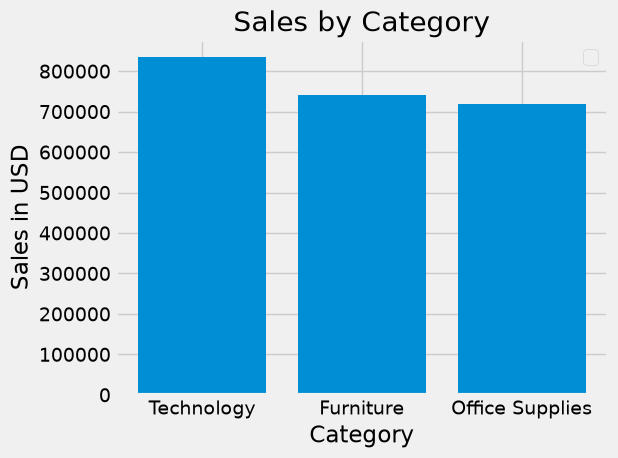

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('superstore_data.csv', encoding='latin1')

##Bar Chart showing which category makes the most money

plt.style.use('fivethirtyeight') # change the style of the plot

sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)



plt.bar(sales_by_category.index, sales_by_category.values)#, color='orange') plt.barh(y-axis, x-axis)

plt.xlabel('Category')
plt.ylabel('Sales in USD')
plt.title('Sales by Category')
    

plt.legend()
plt.tight_layout() # adjust the padding between and around subplots
plt.savefig('Sales by Category.png') # save the plot as a PNG file
plt.show()

    



C:\Users\USER\AppData\Local\Temp\ipykernel_8680\727646966.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\USER\AppData\Local\Temp\ipykernel_8680\727646966.py:23: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout() # adjust the padding between and around subplots


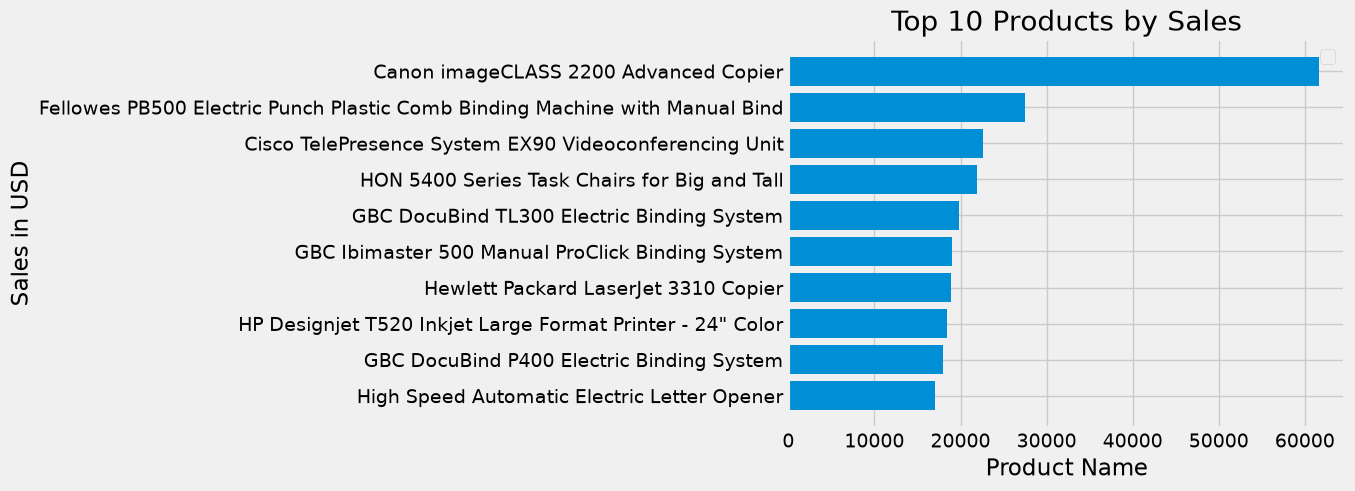

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('superstore_data.csv', encoding='latin1')

##Bar Chart showing which category makes the most money

plt.style.use('fivethirtyeight') # change the style of the plot

top_10_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=True).tail(10)



plt.barh(top_10_products.index, top_10_products.values)#, color='orange') plt.barh(y-axis, x-axis)

plt.xlabel('Product Name')
plt.ylabel('Sales in USD')
plt.title('Top 10 Products by Sales')
    

plt.legend()
plt.tight_layout() # adjust the padding between and around subplots
plt.savefig('Top 10 Products by Sales.png')
plt.show()

    

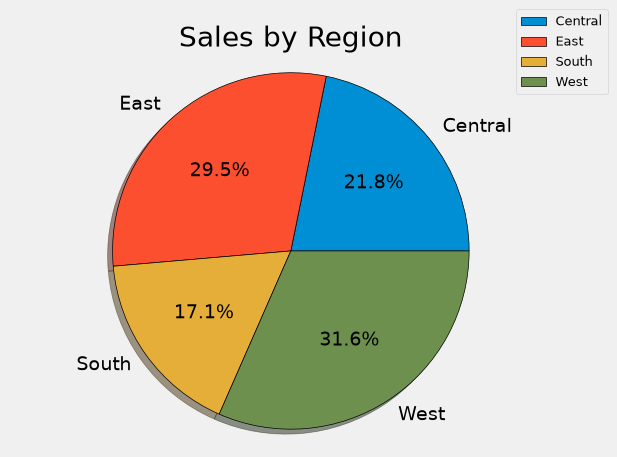

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('superstore_data.csv', encoding='latin1')

##Pie Chart showing which category makes the most money

plt.style.use('fivethirtyeight') # change the style of the plot

sales_by_region = df.groupby('Region')['Sales'].sum()


plt.pie(sales_by_region.values, labels=sales_by_region.index, wedgeprops={'edgecolor': 'black'}, shadow=True, autopct='%1.1f%%')
plt.title('Sales by Region')
plt.axis('equal') # equal aspect ratio ensures that pie is drawn as a circle

    

plt.legend(fontsize=9, loc=(0.9, 0.9))#, bbox_to_anchor=(1, 1)) # place the legend outside the plot
plt.tight_layout() # adjust the padding between and around subplots
plt.savefig('Sales by Region.png') # save the plot as a PNG file
plt.show()

    

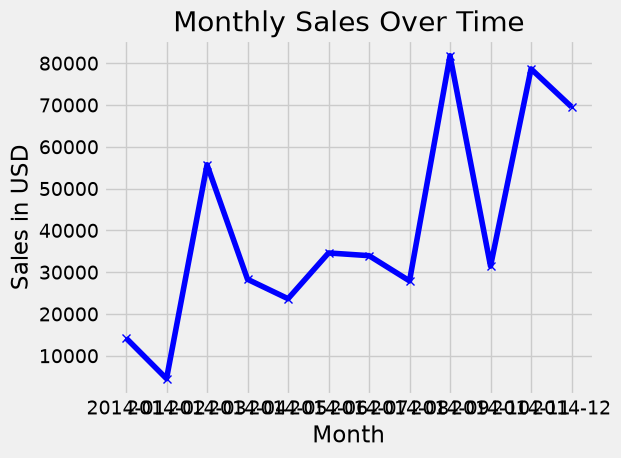

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('superstore_data.csv', encoding='latin1')

##Chart showing sales over time

#Covert Order Date to datetime format (then Monthly sales over time)

df['Order Date'] = pd.to_datetime(df['Order Date'])

Monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().head(12) # get the first 12 months of sales data 

plt.xlabel('Month')
plt.plot(Monthly_sales.index.astype(str), Monthly_sales.values, marker='x', color='blue')

plt.ylabel('Sales in USD')
plt.title('Monthly Sales Over Time')

plt.tight_layout() # adjust the padding between and around subplots
plt.savefig('Monthly Sales Over Time.png')
plt.show()



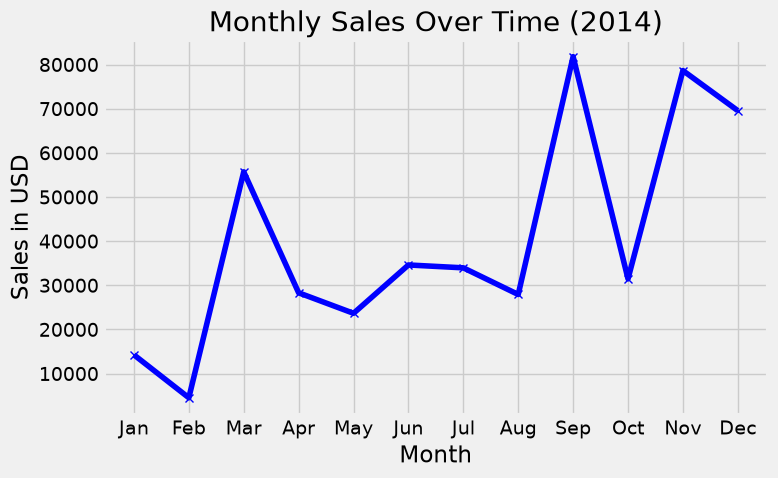

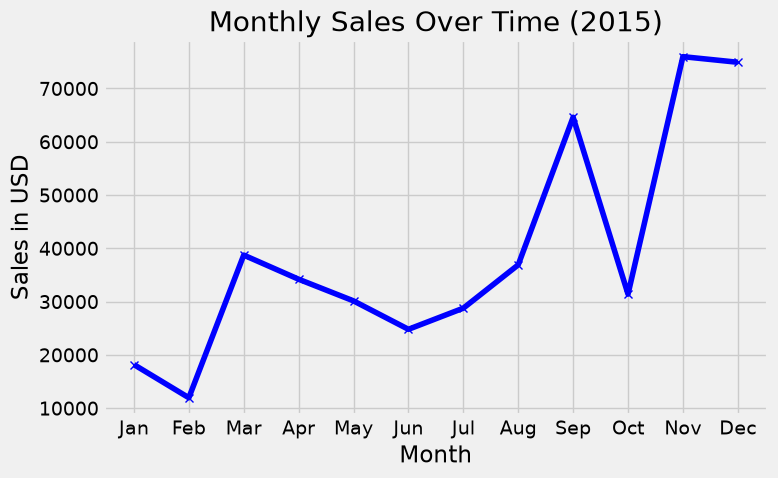

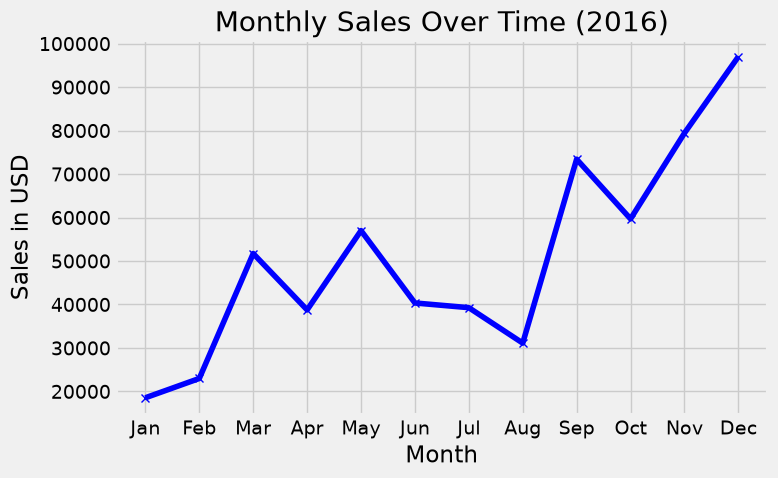

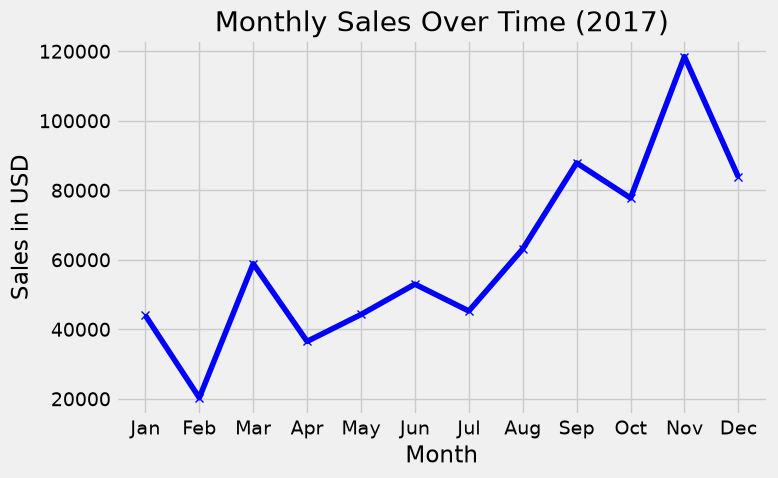

In [2]:
##This Automatically runs for each year and saves the plot as a PNG file 
# unlike the way i did it above where i had to manually change the year and save the plot for each year.

import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('superstore_data.csv', encoding='latin1')

# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract Year and Month
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.strftime('%b')

# Month order
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Loop through each year
for year in sorted(df['Year'].unique()):

    yearly_data = df[df['Year'] == year]

    monthly_sales = (yearly_data.groupby('Month')['Sales'].sum().reindex(month_order))

    plt.figure(figsize=(8, 5))

    plt.plot(monthly_sales.index,monthly_sales.values,marker='x',color='blue')

    plt.xlabel('Month')
    plt.ylabel('Sales in USD')
    plt.title(f'Monthly Sales Over Time ({year})')

    plt.tight_layout()

    plt.savefig(f'Monthly_Sales_{year}.png')
    plt.show()